In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.tree import DecisionTreeClassifier

In [ ]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 200

age = np.random.randint(50, 91, n)

smoker = np.random.choice([0, 1], size=n, p=[0.6, 0.4])

bp = np.random.choice(['0', '1', '2'], size=n, p=[0.2, 0.5, 0.3])

cholesterol = np.random.randint(180, 301, n)

exercise = np.random.choice([0, 1], size=n, p=[0.4, 0.6])

# heart_disease = np.random.choice([0, 1], size=n, p=[0.7, 0.3])

# Create DataFrame
df = pd.DataFrame({
    "age": age,
    "smoker": smoker,
    "bp": bp,
    "cholesterol": cholesterol,
    "exercise": exercise
})

print(df.head())

# Optional: save to CSV
df.to_csv("heart_data.csv", index=False)

In [19]:
df=pd.DataFrame(pd.read_csv("heart_data.csv"))

In [20]:
df

,Age,Smoker,BP,Cholesterol,Exercise,HeartDisease
0,68,no,High,198,Yes,Yes
1,51,yes,Low,163,No,Yes
2,70,yes,Normal,292,No,Yes
3,61,no,Normal,150,Yes,No
4,75,no,Normal,266,Yes,No
...,...,...,...,...,...,...
195,57,no,High,275,No,Yes
196,63,yes,Normal,193,Yes,Yes
197,65,no,Normal,174,No,No
198,63,no,Low,294,Yes,No


In [ ]:
#Rule 1 if age>60 and smoker=1 then heart_disease=1 
#Rule 2 bp=2 and cholesterol>240 then heart_disease=1
#Rule 3 smoker=1 and exercise=0 and age >55 then heart_disease=1

# Create a simple rule-based target (heart disease risk)
risk_score = (
    (df['age'] > 60).astype(int) * 0.3 +
    (df['smoker'] == 1).astype(int) * 0.3 +
    (df['bp'] == '2').astype(int) * 0.2 +
    (df['cholesterol'] > 240).astype(int) * 0.1 +
    (df['exercise'] == 0).astype(int) * 0.1
)

# Convert risk score into probability
prob = risk_score / risk_score.max()

# Heart disease (0/1)
heart_disease = (np.random.rand(n) < prob).astype(int)

df['heart_disease'] = heart_disease

In [58]:
df=pd.DataFrame(pd.read_csv("heart_data.csv"))
df

,Age,Smoker,BP,Cholesterol,Exercise,HeartDisease
0,68,no,High,198,Yes,Yes
1,51,yes,Low,163,No,Yes
2,70,yes,Normal,292,No,Yes
3,61,no,Normal,150,Yes,No
4,75,no,Normal,266,Yes,No
...,...,...,...,...,...,...
195,57,no,High,275,No,Yes
196,63,yes,Normal,193,Yes,Yes
197,65,no,Normal,174,No,No
198,63,no,Low,294,Yes,No


In [59]:
df.head(10)

,Age,Smoker,BP,Cholesterol,Exercise,HeartDisease
0,68,no,High,198,Yes,Yes
1,51,yes,Low,163,No,Yes
2,70,yes,Normal,292,No,Yes
3,61,no,Normal,150,Yes,No
4,75,no,Normal,266,Yes,No
5,55,no,Normal,203,Yes,No
6,72,yes,Low,267,Yes,Yes
7,53,no,High,152,No,No
8,72,no,High,293,Yes,Yes
9,60,yes,High,161,Yes,Yes


In [60]:
df['Smoker'] = df['Smoker'].replace({'no': 0, 'yes': 1})
df['BP'] = df['BP'].replace({'Low': 0, 'Normal': 1, 'High': 2})
df['Exercise'] = df['Exercise'].replace({'Yes': 1, 'No': 0})


In [61]:
df

,Age,Smoker,BP,Cholesterol,Exercise,HeartDisease
0,68,0,2,198,1,Yes
1,51,1,0,163,0,Yes
2,70,1,1,292,0,Yes
3,61,0,1,150,1,No
4,75,0,1,266,1,No
...,...,...,...,...,...,...
195,57,0,2,275,0,Yes
196,63,1,1,193,1,Yes
197,65,0,1,174,0,No
198,63,0,0,294,1,No


In [9]:
import math

# Manual two-proportion z-test (one-sided: p1 > p2)
mask_smoker = df['Smoker'].str.lower() == 'yes'
heart_disease = df['HeartDisease'].str.lower().map({'yes': 1, 'no': 0})
X1 = heart_disease[mask_smoker]   # smokers
X2 = heart_disease[~mask_smoker]  # non-smokers

n1 = len(X1)
n2 = len(X2)
s1 = X1.sum()
s2 = X2.sum()
p1 = s1 / n1
p2 = s2 / n2

# pooled proportion and standard error under H0: p1 = p2
p_pool = (s1 + s2) / (n1 + n2)
se = (p_pool * (1 - p_pool) * (1/n1 + 1/n2)) ** 0.5

z = (p1 - p2) / se

cdf = 0.5 * (1 + math.erf(z / math.sqrt(2)))
p_value_one_sided = 1 - cdf  # test p1 > p2

print(f"n1={n1}, s1={s1}, p1={p1:.4f}")
print(f"n2={n2}, s2={s2}, p2={p2:.4f}")
print(f"pooled p={p_pool:.4f}, se={se:.4f}")
print(f"z={z:.4f}, one-sided p-value={p_value_one_sided:.4f}")

alpha = 0.05
crit = 1.645  # one-sided critical value
print("Decision:", "Reject H0" if z > crit else "Fail to reject H0")


n1=80, s1=66, p1=0.8250
n2=120, s2=22, p2=0.1833
pooled p=0.4400, se=0.0716
z=8.9559, one-sided p-value=0.0000
Decision: Reject H0


In [80]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier
X=df.drop("HeartDisease",axis=1)
y=df["HeartDisease"]

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
model=DecisionTreeClassifier(criterion="entropy",   # "entropy" or "gini"
    max_depth=10,        # limit depth to avoid overfitting
    random_state=42)

# X = pd.get_dummies(X, drop_first=True)
y = y.map({'No': 0, 'Yes': 1})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)

y_pred=model.predict(X_test)

y_pred

array([0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1])

In [63]:
model.score(X_test,y_test)

1.0

In [64]:
from sklearn.metrics import accuracy_score
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred))

Decision Tree Accuracy: 1.0


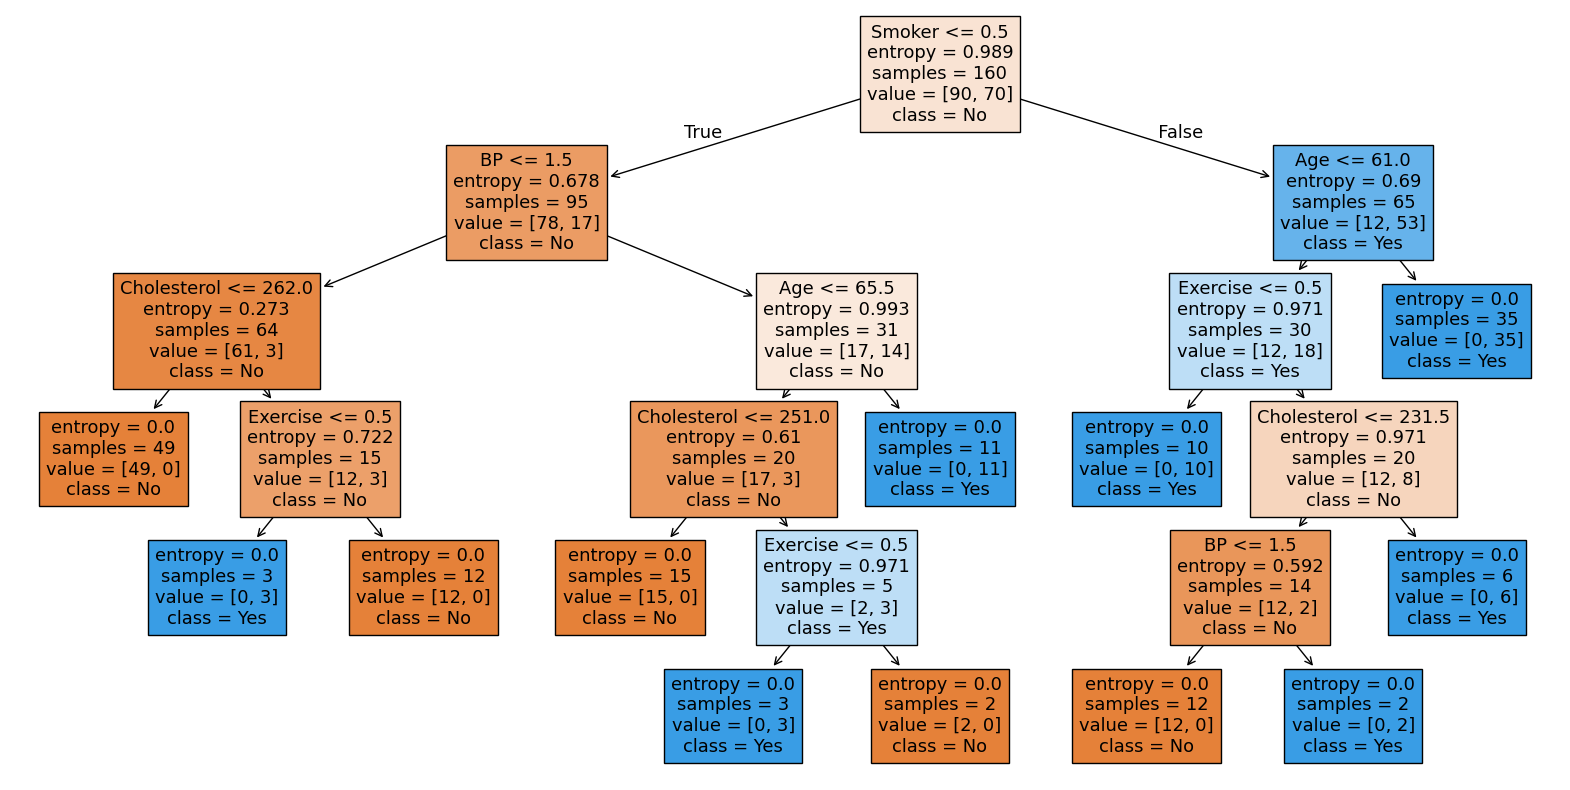

In [65]:
# makind the tree 
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(model, filled=True, feature_names=X.columns, class_names=['No', 'Yes'])
plt.show()

In [66]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 1.0


In [70]:
c=confusion_matrix(y_test, rf_pred)
c


array([[22,  0],
       [ 0, 18]])

In [67]:
from sklearn.metrics import classification_report

report = classification_report(y_test, rf_pred)
print(report)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        22
           1       1.00      1.00      1.00        18

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



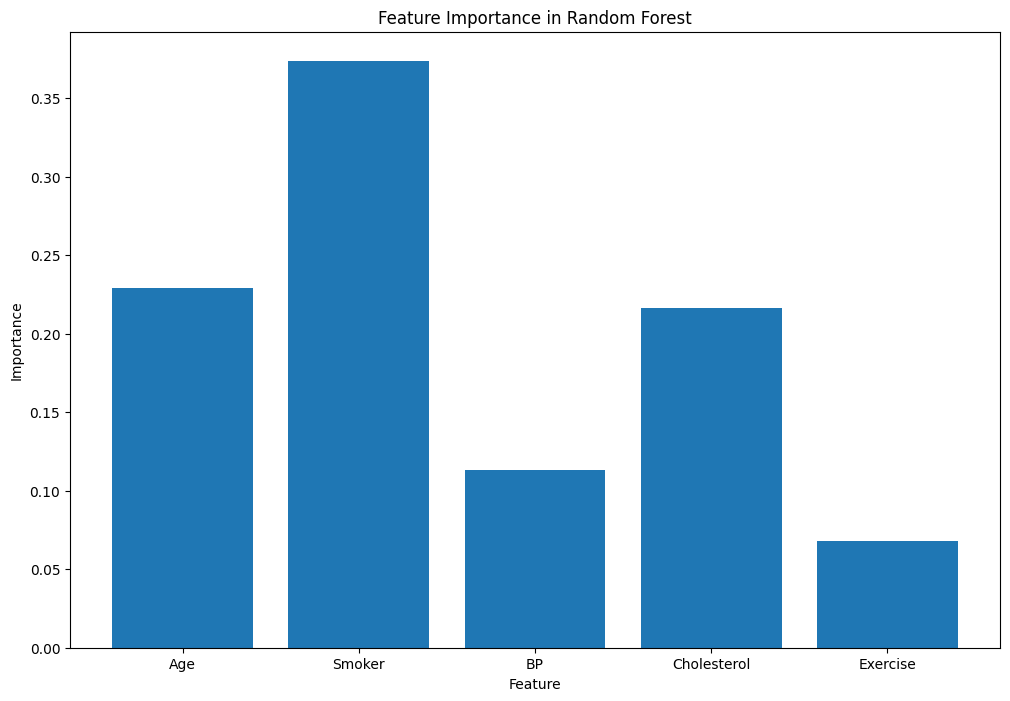

In [72]:
# visualization of feature importance
importances = rf_model.feature_importances_
plt.figure(figsize=(12,8))
plt.bar(range(len(importances)), importances, tick_label=X.columns)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importance in Random Forest")
plt.show()

In [69]:
importances = pd.Series(model.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False))

Smoker         0.309430
Age            0.216949
Exercise       0.160521
Cholesterol    0.158787
BP             0.154313
dtype: float64


# Ada Boosting


In [73]:
from sklearn.ensemble import AdaBoostClassifier
ada_model = AdaBoostClassifier(n_estimators=100, random_state=42)
ada_model.fit(X_train, y_train)
ada_pred = ada_model.predict(X_test)
print("AdaBoost Accuracy:", accuracy_score(y_test, ada_pred))


AdaBoost Accuracy: 0.95


# XGBoost Classifier


In [81]:
import xgboost as xgb
xgb_model = xgb.XGBClassifier(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))


ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:Smoker: object, BP: object, Exercise: object